In [15]:
from tensorflow.keras.datasets import mnist

In [16]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()

In [17]:
x_train.max()

np.uint8(255)

In [18]:
x_train = x_train/255
y_train = y_train/255

In [19]:
print(x_train.shape)
print(x_test.shape)

(60000, 28, 28)
(10000, 28, 28)


In [41]:
x_train = x_train.reshape((-1,28,28,1))
x_test = x_test.reshape((-1, 28,28,1))

In [59]:
import tensorflow as tf  
from tensorflow.keras.layers import Dense, Dropout, Conv2D, Conv2DTranspose, MaxPool2D, BatchNormalization, UpSampling2D
from tensorflow.keras.models import Sequential

In [148]:
# encoder layers

encoder = Sequential(name = 'encoder')
encoder.add(Conv2D(8, kernel_size=(3,3), strides=(1,1), padding='same', activation='relu', input_shape=(28,28,1)))
encoder.add(MaxPool2D((2,2), padding='same'))
encoder.add(Dropout(0.3)) 
encoder.add(Conv2D(16, kernel_size=(3,3), strides=(1,1), padding='same', activation='relu'))
encoder.add(MaxPool2D((2,2), padding='same'))
encoder.add(Dropout(0.3)) 
encoder.add(Conv2D(32, kernel_size=(3,3), strides=(1,1), padding='same', activation='relu'))

# decoder layers

decoder = Sequential(name = 'decoder')
#encoder.add(Conv2D(32, kernel_size=(3,3), strides=(1,1), padding='same', activation='relu', input_shape=(7,7,32)))
decoder.add(UpSampling2D(size=(2,2)))
encoder.add(Conv2D(16, kernel_size=(3,3), padding='same', activation='relu'))
decoder.add(UpSampling2D(size=(2,2)))
decoder.add(Conv2D(8 , kernel_size=(3,3), padding='same', activation='relu'))
decoder.add(BatchNormalization())
decoder.add(Conv2D(1, kernel_size=(3,3),  padding='same', activation='sigmoid'))


# autoencoder architecture

autoencoder = Sequential(name = 'autoencoder')
autoencoder.add(encoder)
# autoencoder.add(Dropout(0.01))
autoencoder.add(decoder)


/Users/taktakro/Desktop/SmallProjects_PY/venv3.12/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [149]:
encoder.summary()

Model: "encoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_96 (Conv2D)              │ (None, 28, 28, 8)      │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_40 (MaxPooling2D) │ (None, 14, 14, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 14, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_97 (Conv2D)              │ (None, 14, 14, 16)     │         1,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_41 (MaxPooling2D) │ (None, 7, 7, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 7, 7, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_98 (Conv2D)              │ (None, 7, 7, 32)       │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_99 (Conv2D)              │ (None, 7, 7, 16)       │         4,624 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,512 (41.06 KB)

 Trainable params: 10,512 (41.06 KB)

 Non-trainable params: 0 (0.00 B)

In [150]:
decoder.summary()

Model: "decoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ up_sampling2d_22 (UpSampling2D) │ (None, 14, 14, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_23 (UpSampling2D) │ (None, 28, 28, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_100 (Conv2D)             │ (None, 28, 28, 8)      │         1,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 28, 28, 8)      │            32 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_101 (Conv2D)             │ (None, 28, 28, 1)      │            73 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,265 (4.94 KB)

 Trainable params: 1,249 (4.88 KB)

 Non-trainable params: 16 (64.00 B)

In [151]:
autoencoder.summary()

Model: "autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ encoder (Sequential)            │ (None, 7, 7, 16)       │        10,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder (Sequential)            │ (None, 28, 28, 1)      │         1,265 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,777 (46.00 KB)

 Trainable params: 11,761 (45.94 KB)

 Non-trainable params: 16 (64.00 B)

In [152]:
opt = tf.keras.optimizers.Adam(.001)
loss= tf.keras.losses.MeanSquaredError()
autoencoder.compile(optimizer=opt, loss=loss)

In [164]:
x_train.shape

(60000, 28, 28, 1)

In [153]:
autoencoder.fit(x_train, x_train, validation_data=(x_test, x_test), batch_size=50, epochs=10, verbose=2)

Epoch 1/10
1200/1200 - 18s - 15ms/step - loss: 0.0248 - val_loss: 7342.9146
Epoch 2/10
1200/1200 - 17s - 14ms/step - loss: 0.0116 - val_loss: 7342.9434
Epoch 3/10
1200/1200 - 17s - 14ms/step - loss: 0.0105 - val_loss: 7342.9502
Epoch 4/10
1200/1200 - 17s - 14ms/step - loss: 0.0100 - val_loss: 7342.9590
Epoch 5/10
1200/1200 - 18s - 15ms/step - loss: 0.0097 - val_loss: 7342.9585
Epoch 6/10
1200/1200 - 18s - 15ms/step - loss: 0.0094 - val_loss: 7342.9561
Epoch 7/10
1200/1200 - 19s - 16ms/step - loss: 0.0092 - val_loss: 7342.9434
Epoch 8/10
1200/1200 - 19s - 16ms/step - loss: 0.0089 - val_loss: 7342.9648
Epoch 9/10
1200/1200 - 17s - 14ms/step - loss: 0.0087 - val_loss: 7342.9766
Epoch 10/10
1200/1200 - 17s - 14ms/step - loss: 0.0085 - val_loss: 7342.9775


In [154]:
x_autoencoder = autoencoder(x_train)

In [155]:
import matplotlib.pyplot as plt
import numpy as np

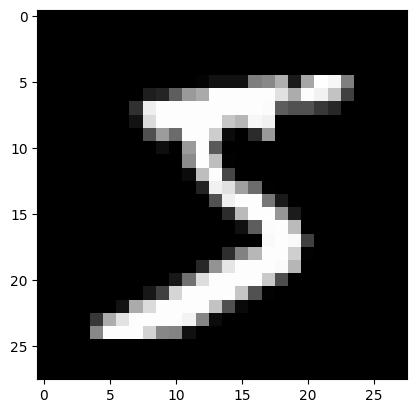

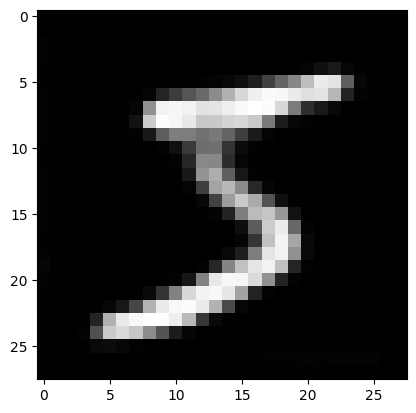

In [156]:
plt.imshow(np.reshape(x_train[0],(28,28)), cmap="gray")
plt.show()
plt.imshow(np.reshape(x_autoencoder[0],(28,28)), cmap="gray")
plt.show()

In [157]:
# encoder
x_code = encoder(x_train)

In [158]:
x_code.shape

TensorShape([60000, 7, 7, 16])

In [159]:
x_decode = decoder(x_code)

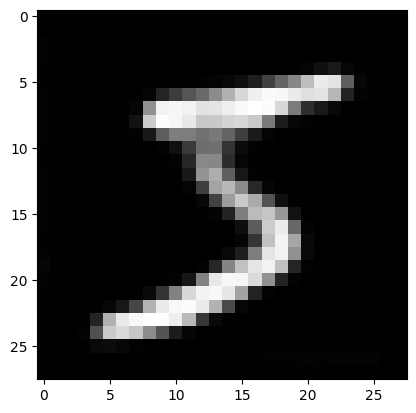

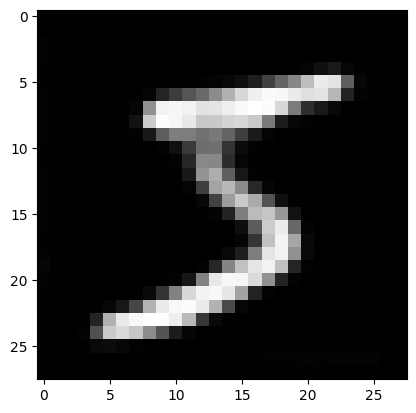

In [160]:
plt.imshow(np.reshape(x_decode[0],(28,28)), cmap="gray")
plt.show()
plt.imshow(np.reshape(x_autoencoder[0],(28,28)), cmap="gray")
plt.show()

In [161]:
x1 = x_decode[1] - x_autoencoder[1]
x2 = x_train[1] - x_autoencoder[1]

In [162]:
np.sum(x1)

np.float32(0.0)

In [163]:
np.sum(x2)

np.float32(27.229296)